In [4]:
#Change Working Directory
import os
os.chdir('F:/Programming with R and Python')
#Current working directory
print(os.getcwd())
print()
os.listdir()

F:\Programming with R and Python



['.RData',
 '.Rhistory',
 'Assignment based on airline data in RStudio.R',
 'flight_data.csv',
 'ggplot practice.R',
 'Histogram-Question 1.png',
 'lung_disease.csv',
 'programming R.R',
 'Python lec 1.ipynb',
 'real_estate.sav',
 'Real_Estate_Data_SPSS.xlsx',
 'report.html',
 'sales.csv',
 'sales.xlsx',
 'self practice.R',
 'STAT 2205 (raw data-assignment).R',
 'STAT 2205 (real estate xlsx _assignment).R',
 'STAT 2205 (real_estate.sav-assignment).R',
 'STAT 2205 (sales.csv assignment).R',
 'STAT 2205 (sales.xls-assignment).R']

In [5]:
#read csv data
import pandas as pd
flight=pd.read_csv('flight_data.csv')
flight.head()

,miles,passengers,delay,inflight_meal,inflight_entertainment,inflight_wifi,day_of_week,redeye,weekend,coach_price,firstclass_price,hours
0,792,172,0,No,Yes,Yes,Sunday,Yes,Yes,338.820,1571.02,1
1,3163,214,0,No,Yes,Yes,Sunday,No,Yes,472.655,1663.70,6
2,1832,212,0,No,Yes,No,Friday,No,Yes,351.960,1429.86,3
3,925,213,0,No,Yes,Yes,Saturday,No,Yes,387.835,1558.76,2
4,967,217,0,Yes,Yes,Yes,Monday,No,No,374.735,1245.58,2


In [6]:
## Select random sample
airline_rs = flight.sample(n=12339, random_state=12339)
print(airline_rs)


        miles  passengers  delay inflight_meal inflight_entertainment  \
32472    2507         218     11            No                     No   
96923    2369         232      9           Yes                    Yes   
47639     835         219     10            No                    Yes   
119178   1756         210     33            No                    Yes   
69860    2440         208     11           Yes                    Yes   
...       ...         ...    ...           ...                    ...   
16083    2012         205     10            No                    Yes   
68079     589         209     13            No                    Yes   
126999   1829         204     37            No                     No   
112937   3234         215     19            No                    Yes   
64620    2036         201     10           Yes                    Yes   

       inflight_wifi day_of_week redeye weekend  coach_price  \
32472            Yes      Friday     No     Yes      354.98

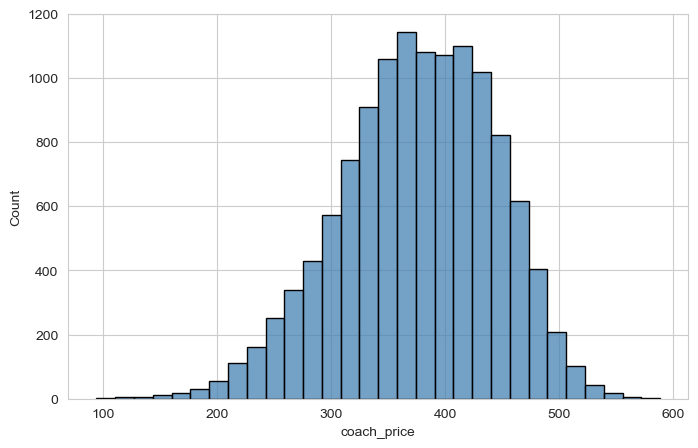

Max: 588.335
Min: 94.535
Mean: 376.1661650052679


In [14]:
#question 1
##What do coach ticket price look like ?
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.histplot(
    data=airline_rs,
    x="coach_price",
    bins=30,
    color="steelblue",
    edgecolor="black"
)
import matplotlib.pyplot as plot
plot.savefig("Histogram-Question 1",dpi=300,bbox_inches="tight")
plt.show()

#high and low values,average
print("Max:", airline_rs["coach_price"].max())
print("Min:", airline_rs["coach_price"].min())
print("Mean:", airline_rs["coach_price"].mean())

In [37]:
airline_rs.columns

Index(['miles', 'passengers', 'delay', 'inflight_meal',
       'inflight_entertainment', 'inflight_wifi', 'day_of_week', 'redeye',
       'weekend', 'coach_price', 'firstclass_price', 'hours'],
      dtype='object')

In [38]:
###question 2
#What are the prices for 8-hour flights?
flight_8hr = airline_rs[airline_rs["hours"] == 8]
max_price = flight_8hr["coach_price"].max()
min_price = flight_8hr["coach_price"].min()
mean_price = flight_8hr["coach_price"].mean()

print("Max Coach Price (8-hour flight):", max_price)
print("Min Coach Price (8-hour flight):", min_price)
print("Average Coach Price (8-hour flight):", mean_price)

Max Coach Price (8-hour flight): 589.985
Min Coach Price (8-hour flight): 275.39
Average Coach Price (8-hour flight): 437.31280155642025


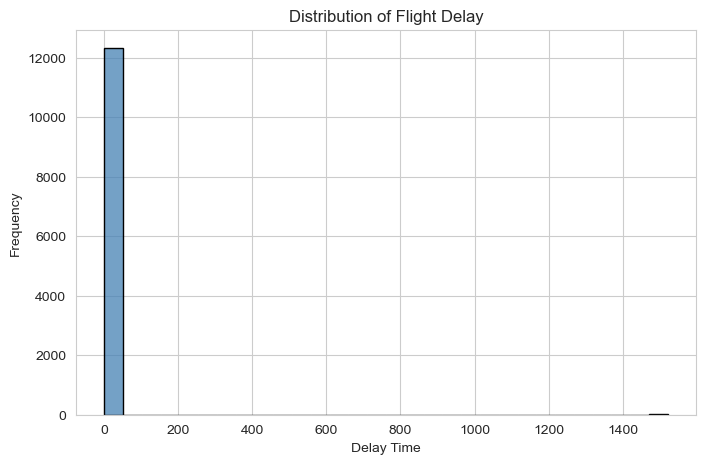

count    12339.000000
mean        14.110382
std         55.564262
min          0.000000
25%          9.000000
50%         10.000000
75%         13.000000
max       1522.000000
Name: delay, dtype: float64

In [7]:
#question 3
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.histplot(
    data=airline_rs,
    x="delay",
    bins=30,
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Flight Delay")
plt.xlabel("Delay Time")
plt.ylabel("Frequency")

import matplotlib.pyplot as plt
plt.savefig("Histogram-Question 3",dpi=300,bbox_inches="tight")

plt.show()
#summary
airline_rs["delay"].describe()


In [40]:
#question 4
import pandas as pd

correlation = airline_rs[['coach_price',
                          'miles',
                          'passengers',
                          'delay',
                          'hours']].corr()['coach_price']

print(correlation)

coach_price    1.000000
miles          0.359655
passengers     0.166628
delay         -0.005054
hours          0.353370
Name: coach_price, dtype: float64


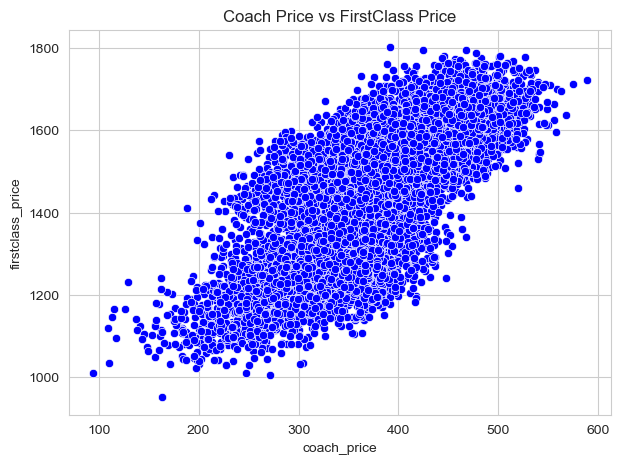

                            OLS Regression Results                            
Dep. Variable:       firstclass_price   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                 1.641e+04
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        18:50:20   Log-Likelihood:                -75119.
No. Observations:               12339   AIC:                         1.502e+05
Df Residuals:                   12337   BIC:                         1.503e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         771.1943      5.411    142.518      

In [8]:
#question 5
#scatter plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=airline_rs,
    x="coach_price",
    y="firstclass_price",
    color="blue"
)

plt.title("Coach Price vs FirstClass Price")
import matplotlib.pyplot as plt
plt.savefig("Histogram-Question 5",dpi=300,bbox_inches="tight")

plt.show()

#correlation
airline_rs[["coach_price", "firstclass_price"]].corr()
#linear regression model
import statsmodels.api as sm

X = airline_rs[["coach_price"]]
y = airline_rs["firstclass_price"]

X = sm.add_constant(X)  # intercept add

model = sm.OLS(y, X).fit()
print(model.summary())
#summary
import statsmodels.api as sm

X = airline_rs[["coach_price"]]
y = airline_rs["firstclass_price"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())



In [44]:
#question 6
import statsmodels.api as sm
# Convert categorical
for col in ["inflight_meal", "inflight_entertainment", "inflight_wifi"]:
    airline_rs[col] = airline_rs[col].astype("category").cat.codes
# 2. Define X and y
X = airline_rs[
    ["inflight_meal",
     "inflight_entertainment",
     "inflight_wifi"]]
y = airline_rs["coach_price"]
# 3. Add constant (intercept)
X = sm.add_constant(X)
# 4. Fit multiple linear regression
model = sm.OLS(y, X).fit()
# 5. Output (like R summary)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            coach_price   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.290
Method:                 Least Squares   F-statistic:                     1680.
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        13:33:05   Log-Likelihood:                -67474.
No. Observations:               12339   AIC:                         1.350e+05
Df Residuals:                   12335   BIC:                         1.350e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    250

Correlation (hours vs passengers): -0.0022597082522336017
                            OLS Regression Results                            
Dep. Variable:                  hours   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.06300
Date:                Mon, 18 May 2026   Prob (F-statistic):              0.802
Time:                        19:54:28   Log-Likelihood:                -24342.
No. Observations:               12339   AIC:                         4.869e+04
Df Residuals:                   12337   BIC:                         4.870e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

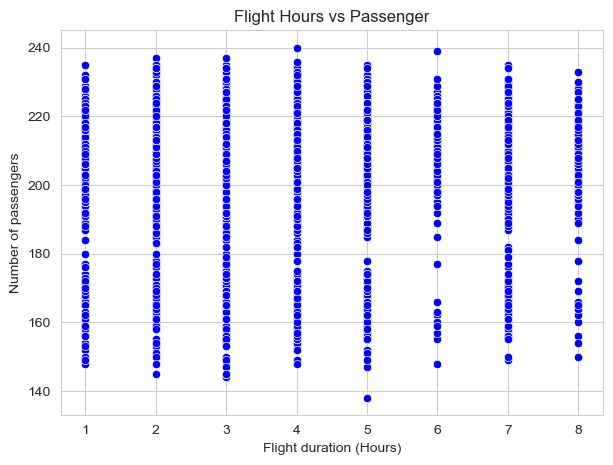

In [9]:
#question 7
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

#Correlation
corr_value = airline_rs["hours"].corr(airline_rs["passengers"])
print("Correlation (hours vs passengers):", corr_value)

# Linear Regression
X = airline_rs[["passengers"]]
y = airline_rs["hours"]

X = sm.add_constant(X)

model_passenger = sm.OLS(y, X).fit()

print(model_passenger.summary())

# Scatter Plot
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=airline_rs,
    x="hours",
    y="passengers",
    color="blue"
)

plt.title("Flight Hours vs Passenger")
plt.xlabel("Flight duration (Hours)")
plt.ylabel("Number of passengers")
plt.savefig("Scatterplot-Question 5",dpi=300,bbox_inches="tight")
plt.show()


Weekday Data:
Empty DataFrame
Columns: [miles, passengers, delay, inflight_meal, inflight_entertainment, inflight_wifi, day_of_week, redeye, weekend, coach_price, firstclass_price, hours]
Index: []
Weekend Data:
Empty DataFrame
Columns: [miles, passengers, delay, inflight_meal, inflight_entertainment, inflight_wifi, day_of_week, redeye, weekend, coach_price, firstclass_price, hours]
Index: []


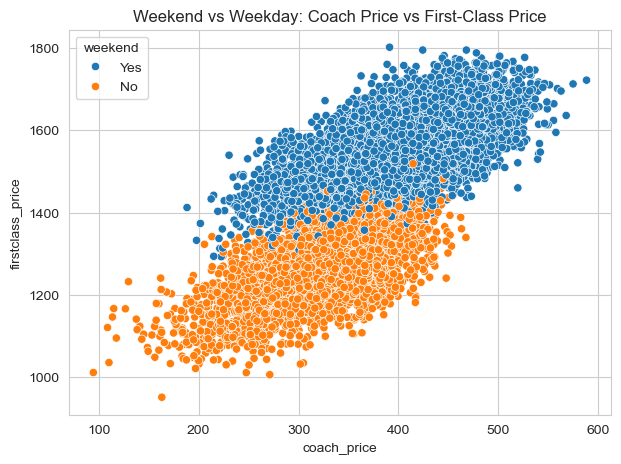

                            OLS Regression Results                            
Dep. Variable:            coach_price   R-squared:                       0.347
Model:                            OLS   Adj. R-squared:                  0.347
Method:                 Least Squares   F-statistic:                     6558.
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        20:37:09   Log-Likelihood:                -66904.
No. Observations:               12339   AIC:                         1.338e+05
Df Residuals:                   12337   BIC:                         1.338e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        321.8152      0.833    386.403      0.0

In [11]:
#question 8
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Weekend & Weekday split
weekend_data = airline_rs[airline_rs["weekend"] == 1]
weekday_data = airline_rs[airline_rs["weekend"] == 0]

print("Weekday Data:")
print(weekday_data.head())
print("Weekend Data:")
print(weekend_data.head())

#Scatter plot (weekend vs weekday)
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=airline_rs,
    x="coach_price",
    y="firstclass_price",
    hue="weekend"
)

plt.title("Weekend vs Weekday: Coach Price vs First-Class Price")
plt.savefig("Scatter plot-Question 8",dpi=300,bbox_inches="tight")

plt.show()


import statsmodels.api as sm
df = airline_rs.copy()
# FORCE CLEAN numeric conversion
df["coach_price"] = pd.to_numeric(df["coach_price"], errors="coerce")
df["weekend"] = df["weekend"].astype(str).str.strip()
df["weekend"] = df["weekend"].map({"Yes": 1, "No": 0})
df["day_of_week"] = df["day_of_week"].astype("category").cat.codes
# drop bad rows
df = df.dropna(subset=["coach_price", "weekend", "day_of_week"])

# MODEL 1
X1 = sm.add_constant(df[["weekend"]])
y1 = df["coach_price"]
model1 = sm.OLS(y1, X1).fit()
print(model1.summary())

# MODEL 2
X2 = sm.add_constant(df[["day_of_week"]])
y2 = df["coach_price"]
model2 = sm.OLS(y2, X2).fit()
print(model2.summary())

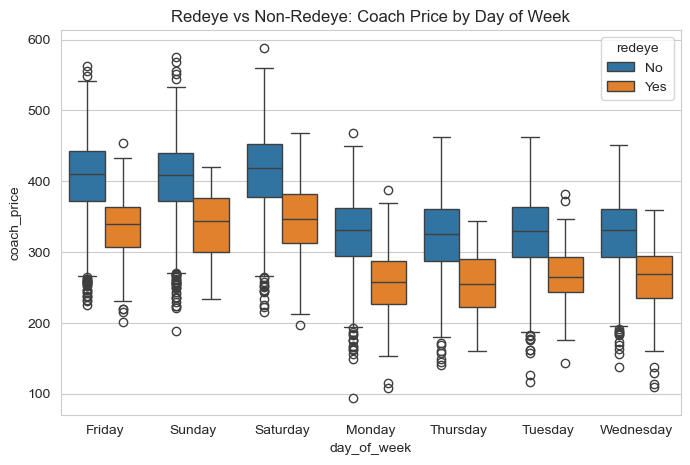


Mean Comparison (coach_price ~ day_of_week + redeye):
day_of_week  redeye
Friday       No        405.972703
             Yes       331.546200
Monday       No        325.582162
             Yes       258.864257
Saturday     No        414.376136
             Yes       345.873571
Sunday       No        404.722288
             Yes       337.658319
Thursday     No        321.703371
             Yes       258.688750
Tuesday      No        325.322532
             Yes       267.461271
Wednesday    No        326.414200
             Yes       257.426818
Name: coach_price, dtype: float64


In [12]:
#question 9
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# COPY DATA (safe)
df = airline_rs.copy()
# Ensure correct types
df["coach_price"] = pd.to_numeric(df["coach_price"], errors="coerce")
df["day_of_week"] = df["day_of_week"].astype(str)
df["redeye"] = df["redeye"].astype(str)

# BOXPLOT (R ggplot equivalent)
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="day_of_week",
    y="coach_price",
    hue="redeye"
)

plt.title("Redeye vs Non-Redeye: Coach Price by Day of Week")
plt.savefig("Box plot-Question 9",dpi=300,bbox_inches="tight")
plt.show()

# MEAN COMPARISON (R aggregate equivalent)
mean_table = df.groupby(["day_of_week", "redeye"])["coach_price"].mean()

print("\nMean Comparison (coach_price ~ day_of_week + redeye):")
print(mean_table)


MEAN:
 miles               2007.852986
passengers           207.720156
delay                 14.110382
coach_price          376.166165
firstclass_price    1453.449748
hours                  3.633115
dtype: float64

MEDIAN:
 miles               1992.00
passengers           209.00
delay                 10.00
coach_price          378.96
firstclass_price    1500.72
hours                  4.00
dtype: float64

STD:
 miles               946.162399
passengers           12.612948
delay                55.564262
coach_price          67.789068
firstclass_price    162.724590
hours                 1.739944
dtype: float64


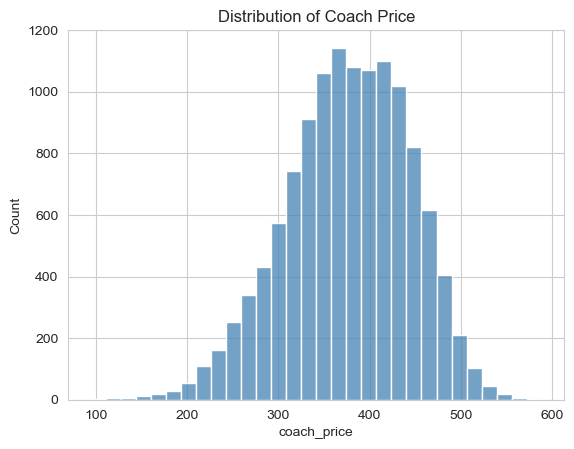

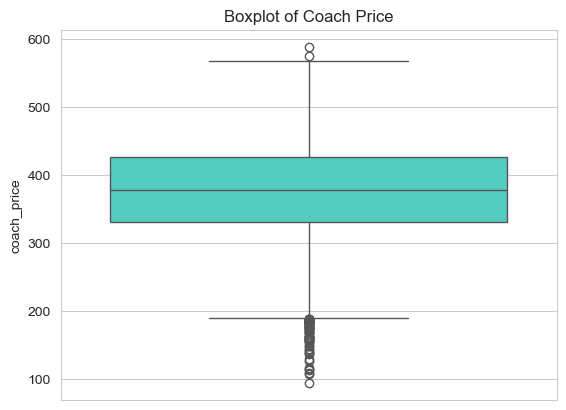

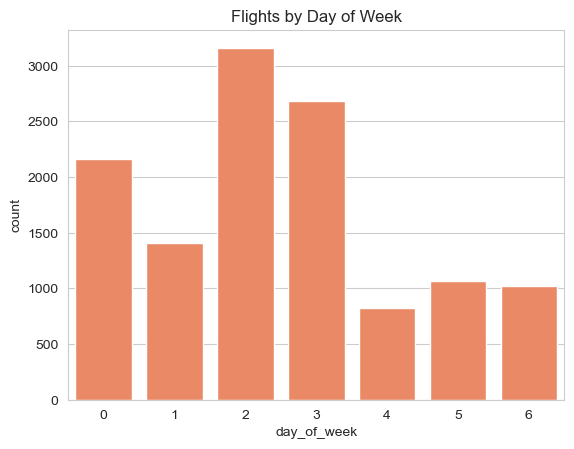

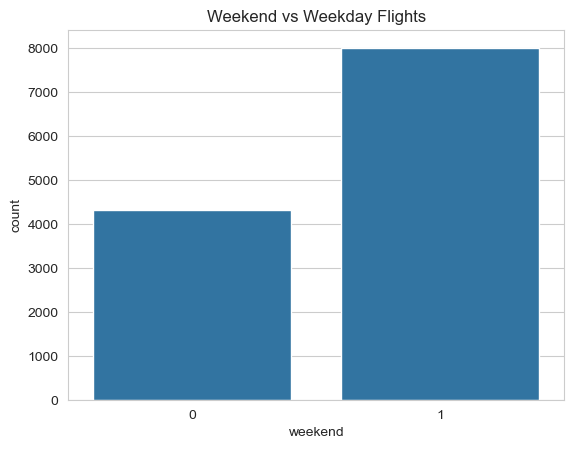

TtestResult(statistic=np.float64(80.98114487036905), pvalue=np.float64(0.0), df=np.float64(12337.0))
Z-score: 452.53355749907325
Chi2ContingencyResult(statistic=np.float64(0.03532293017466096), pvalue=np.float64(0.8509205856437194), dof=1, expected_freq=array([[4115.64259664,  210.35740336],
       [7623.35740336,  389.64259664]]))
TtestResult(statistic=np.float64(80.98114487036905), pvalue=np.float64(0.0), df=np.float64(12337.0))
weekend
0    321.815175
1    405.508781
Name: coach_price, dtype: float64
                  coach_price  firstclass_price     miles     hours  \
coach_price          1.000000          0.755568  0.336359  0.329411   
firstclass_price     0.755568          1.000000  0.290992  0.285578   
miles                0.336359          0.290992  1.000000  0.985743   
hours                0.329411          0.285578  0.985743  1.000000   
passengers           0.166545          0.024447 -0.003260 -0.002260   
delay               -0.004101         -0.006792 -0.015459 -0.0158

In [13]:
###question 10
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
df = airline_rs.copy()
# 1. SUMMARY STATISTICS
num_cols = ["miles","passengers","delay","coach_price","firstclass_price","hours"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nMEAN:\n", df[num_cols].mean())
print("\nMEDIAN:\n", df[num_cols].median())
print("\nSTD:\n", df[num_cols].std())

# 2. VISUALIZATION
# Histogram
plt.figure()
sns.histplot(df["coach_price"], bins=30, color="steelblue")
plt.title("Distribution of Coach Price")
plt.savefig("Histogram-Question 10",dpi=300,bbox_inches="tight")
plt.show()

# Boxplot
plt.figure()
sns.boxplot(y=df["coach_price"], color="turquoise")
plt.title("Boxplot of Coach Price")
plt.savefig("Box plot-Question 10",dpi=300,bbox_inches="tight")
plt.show()

# Bar chart (day_of_week)
df["day_of_week"] = df["day_of_week"].astype("category").cat.codes

plt.figure()
sns.countplot(x="day_of_week", data=df, color="coral")
plt.title("Flights by Day of Week")
plt.savefig("Bar chart-Question 10",dpi=300,bbox_inches="tight")
plt.show()

# Weekend bar chart
df["weekend"] = df["weekend"].astype("category").cat.codes

plt.figure()
sns.countplot(x="weekend", data=df)
plt.title("Weekend vs Weekday Flights")
plt.savefig("Weekend bar chart-Question 10",dpi=300,bbox_inches="tight")
plt.show()

# 3. HYPOTHESIS TESTING
# t-test (weekend effect)
print(stats.ttest_ind(
    df[df["weekend"]==1]["coach_price"],
    df[df["weekend"]==0]["coach_price"],
    nan_policy="omit"
))

# z-test (manual)
z = (df["coach_price"].mean() - 100) / (df["coach_price"].std()/np.sqrt(len(df)))
print("Z-score:", z)

# chi-square test
chi_table = pd.crosstab(df["weekend"], df["redeye"].astype("category").cat.codes)
print(stats.chi2_contingency(chi_table))

# 4.independent t-test again
print(stats.ttest_ind(
    df[df["weekend"]==1]["coach_price"],
    df[df["weekend"]==0]["coach_price"],
    nan_policy="omit"
))

#5. price difference
print(df.groupby("weekend")["coach_price"].mean())

# 6. CORRELATION
print(df[["coach_price","firstclass_price","miles","hours","passengers","delay"]].corr())

# 7. REGRESSION ANALYSIS
# Model 1
cat_cols = ["inflight_meal","inflight_entertainment","inflight_wifi"]

for col in cat_cols:
    df[col] = df[col].astype("category").cat.codes

X1 = df[cat_cols + ["miles","passengers"]]
y1 = df["coach_price"]

X1 = sm.add_constant(X1)
model1 = sm.OLS(y1, X1).fit()

print(model1.summary())

# 8. PRICE PREDICTION MODEL
X2 = df[["coach_price","miles","passengers"]]
y2 = df["firstclass_price"]

X2 = sm.add_constant(X2)
model2 = sm.OLS(y2, X2).fit()

print(model2.summary())

# 9. LOGISTIC REGRESSION (Redeye)
df["redeye"] = df["redeye"].astype("category").cat.codes

y3 = df["redeye"]
X3 = df[["coach_price","miles","passengers","delay"]]

X3 = sm.add_constant(X3)

log_model = sm.Logit(y3, X3).fit()

print(log_model.summary())